# A Máquina do Tempo Financeira da Indústria Cinematográfica

**Objetivo:** Compreender a evolução do modelo de negócio do cinema ao longo das décadas, analisando como o risco financeiro (Orçamentos) e o sucesso comercial (Receitas) escalaram na era moderna.

### Perguntas de Negócio
1. **A Inflação do Entretenimento:** Como evoluíram os Orçamentos Médios e as Receitas Médias do cinema ao longo das décadas?
   
2. **A Era do Blockbuster:** A partir de que momento histórico é que a indústria do cinema começou a operar com receitas na casa dos milhares de milhões de dólares?
   
3. **Margem de Lucro (ROI - Return On Investment):** O aumento gigantesco dos orçamentos nas últimas décadas traduziu-se num aumento proporcional da rentabilidade (ROI), ou a indústria está assumir mais riscos por margens menores?

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas_datareader.data as web # Biblioteca para consumir APIs financeiras

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf

---
## Caminho central para a base de dados relacional


In [3]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## A Inflação do Entretenimento 

In [4]:
query_decadas = """
    SELECT 
        ROUND(AVG(budget), 2) AS 'orcamento_medio',
        ROUND(AVG(revenue), 2) AS 'faturamento_medio',
        decade 
    FROM unified_media_catalog 
    WHERE media_type = 'Movie' 
    GROUP BY decade
    ORDER BY 
        orcamento_medio DESC, 
        faturamento_medio DESC;
"""

df_decadas = dbc.execute_query(
    caminho_banco,
    alvo=query_decadas, 
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df=df_decadas,
        caption='Relatório Financeiro Através das Décadas'
    )
    .bar(subset=['orcamento_medio'],color='#D4A373')
    .bar(subset=['faturamento_medio'],color='#588157')
    .format({
        'orcamento_medio': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}',
        'faturamento_medio': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
    })
)


Dados carregados via SQL! Formato: (15, 3)


,orcamento_medio,faturamento_medio,decade
0,"US$ 27,203,255.66","US$ 79,558,100.44",2000
1,"US$ 26,190,648.41","US$ 64,111,293.13",1990
2,"US$ 25,564,266.61","US$ 90,898,374.35",2010
3,"US$ 11,368,329.57","US$ 36,517,681.32",1980
4,"US$ 4,827,756.69","US$ 26,623,865.74",1960
5,"US$ 4,363,765.01","US$ 47,500,679.07",1970
6,"US$ 3,390,127.22","US$ 3,046,327.31",1920
7,"US$ 2,395,612.06","US$ 23,579,749.70",1950
8,"US$ 1,636,960.62","US$ 15,411,126.25",1940
9,"US$ 1,284,356.00","US$ 6,784,341.25",1910


#### Ajustar Valores com a Inflação Média da Década

In [5]:
# Ajuste De Inflação (Via api FRED - Federal Reserve)

df_inflacao = df_decadas.copy()

df_cpi = web.DataReader(
    'CPIAUCNS', 
    'fred', 
    datetime.datetime(1910, 1, 1), 
    datetime.datetime(2023, 12, 31)
)

# Transformações
df_cpi = df_cpi.reset_index()
df_cpi['year'] = df_cpi['DATE'].dt.year
df_cpi['decade'] = (df_cpi['year'] // 10) * 10

# Média do índice por década
cpi_decadas = df_cpi.groupby('decade')['CPIAUCNS'].mean().reset_index()

# Âncora de 2023
cpi_atual = df_cpi[df_cpi['year'] == 2023]['CPIAUCNS'].mean()

# Multiplicador
cpi_decadas['fator_inflacao'] = cpi_atual / cpi_decadas['CPIAUCNS']
cpi_decadas['decade'] = cpi_decadas['decade'].astype(int)
df_decadas['decade'] = df_decadas['decade'].astype(int)

# Apaga colunas velhas 
colunas_lixo = [col for col in df_decadas.columns if 'fator_inflacao' in col or 'Ajustado' in col]
df_decadas = df_decadas.drop(columns=colunas_lixo, errors='ignore')

# O Merge final, limpo e com todas as décadas!
df_decadas = df_decadas.merge(cpi_decadas[['decade', 'fator_inflacao']], on='decade', how='left')

# Cálculos Ajustados
df_decadas['orcamento_ajustado'] = df_decadas['orcamento_medio'] * df_decadas['fator_inflacao']
df_decadas['faturamento_ajustado'] = df_decadas['faturamento_medio'] * df_decadas['fator_inflacao']

# Ordenar cronologicamente
df_inflacao = df_decadas.sort_values('decade')

In [6]:
df_exibicao = (
    df_inflacao
    .set_index('decade')
    [
        [
            'orcamento_medio',
            'orcamento_ajustado',
            'faturamento_medio',
            'faturamento_ajustado',
            'fator_inflacao'
        ]
    ]
)

display(
    tb.estilizar_tabela(
        df=df_exibicao,
        caption='Valores Financeiros Ajustados pela Inflação (Base 2023)'
    )
    .background_gradient(subset=['orcamento_medio'], cmap='YlOrBr')
    .background_gradient(subset=['orcamento_ajustado'], cmap='Oranges')
    .background_gradient(subset=['faturamento_medio'], cmap='Greens')
    .background_gradient(subset=['faturamento_ajustado'], cmap='YlGn')
    .background_gradient(subset=['fator_inflacao'], cmap='Purples')
    .format({**
        {
            col: lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
            for col in df_exibicao.columns[:-1]
        },
        'fator_inflacao': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}x'
    })
)

,orcamento_medio,orcamento_ajustado,faturamento_medio,faturamento_ajustado,fator_inflacao
decade,,,,,
1870,NaN,NaN,NaN,NaN,NaN
1880,NaN,NaN,NaN,NaN,NaN
1890,NaN,NaN,NaN,NaN,NaN
1900,"US$ 6,742.50",NaN,NaN,NaN,NaN
1910,"US$ 1,284,356.00","US$ 31,819,771.34","US$ 6,784,341.25","US$ 168,081,269.72",24.77x
1920,"US$ 3,390,127.22","US$ 58,780,944.52","US$ 3,046,327.31","US$ 52,819,845.68",17.34x
1930,"US$ 974,881.00","US$ 20,942,209.10","US$ 19,558,079.37","US$ 420,142,958.77",21.48x
1940,"US$ 1,636,960.62","US$ 26,580,575.15","US$ 15,411,126.25","US$ 250,242,183.28",16.24x
1950,"US$ 2,395,612.06","US$ 27,010,056.90","US$ 23,579,749.70","US$ 265,857,060.80",11.27x


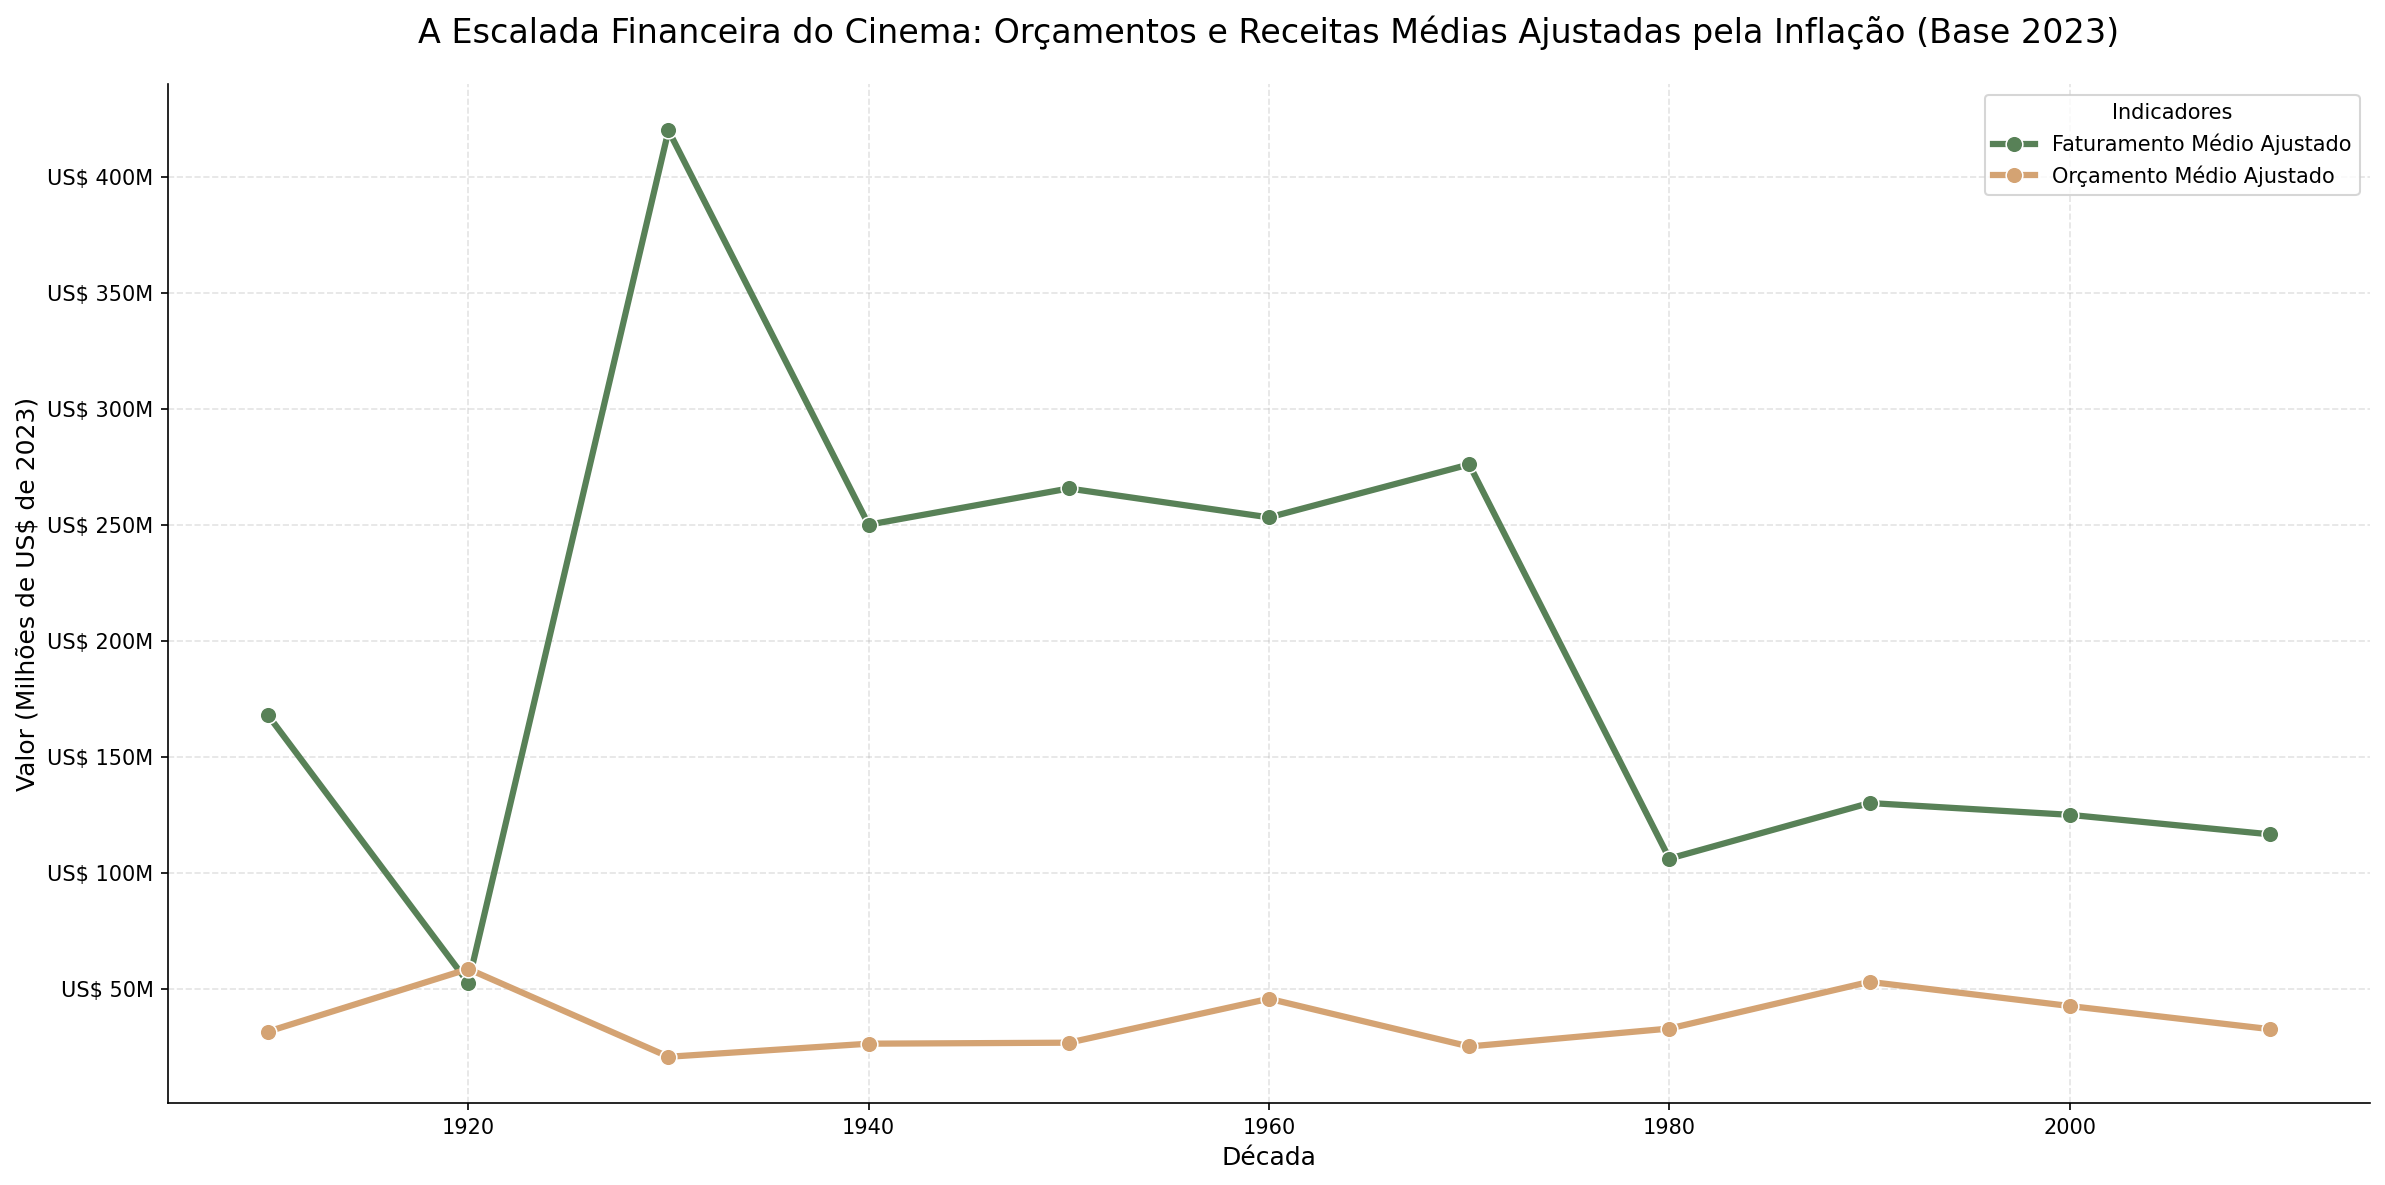

In [7]:
df_inflacao_limpo = df_inflacao.dropna(
    subset=['orcamento_ajustado', 'faturamento_ajustado']
)

# Gráfico: A evolução financeira do cinema ajustada pela inflação

plt.figure(figsize=(16, 8), dpi=150)

ax = sns.lineplot(
    data=df_inflacao_limpo,
    x='decade',
    y='faturamento_ajustado',
    marker='o',
    markersize=8,
    color='#588157',
    linewidth=3,
    label='Faturamento Médio Ajustado'
)

sns.lineplot(
    data=df_inflacao_limpo,
    x='decade',
    y='orcamento_ajustado',
    marker='o',
    markersize=8,
    color='#D4A373',
    linewidth=3,
    label='Orçamento Médio Ajustado',
    ax=ax
)


# Título e rótulos
ax.set_title(
    'A Escalada Financeira do Cinema: Orçamentos e Receitas Médias Ajustadas pela Inflação (Base 2023)',
    fontsize=16,
    pad=20
)

ax.set_xlabel('Década', fontsize=12)
ax.set_ylabel('Valor (Milhões de US$ de 2023)', fontsize=12)

# Formatação do eixo Y em milhões
formatter = ticker.FuncFormatter(
    lambda x, pos: f'US$ {x * 1e-6:.0f}M'
)
ax.yaxis.set_major_formatter(formatter)

# Melhorias visuais
ax.grid(
    True,
    linestyle='--',
    alpha=0.35
)

ax.legend(
    title='Indicadores',
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

### Salvando Nova Tabela (cinema_financeiro_decada)

In [20]:
dbc.save_db(
    df=df_inflacao_limpo,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='cinema_financeiro_decada'
)


Sucesso! Tabela 'cinema_financeiro_decada' criada no banco: 'unified_media_catalog.db'


---
## A Era do Blockbuster

In [ ]:
query_bloc = """
    SELECT
        decade,
        COUNT(*) AS quantidade_blockbusters,
        MAX(revenue) AS maior_faturamento
    FROM (
        SELECT 
            decade,
            revenue,
            PERCENT_RANK() OVER (
                PARTITION BY decade
                ORDER BY revenue DESC
            ) AS ranking
        FROM unified_media_catalog
        WHERE media_type = 'Movie'
    )
    WHERE ranking <= 0.05
    GROUP BY decade
    ORDER BY quantidade_blockbusters DESC;
"""

df_bloc = dbc.execute_query(
    caminho_banco,
    alvo=query_bloc,
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df=df_bloc,
        caption='Blockbuster por Década'
    )
    .bar(
        subset=['quantidade_blockbusters'],
        color='#457B9D'
    )
    .background_gradient(
        subset=['maior_faturamento'],
        cmap='Greens'
    )
    .format({
        'quantidade_blockbusters': '{:,.0f}',
        'maior_faturamento': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
    })
)


Dados carregados via SQL! Formato: (15, 3)


,decade,quantidade_blockbusters,maior_faturamento
0,1950,"1,902","US$ 572,000,000.00"
1,1940,"1,362","US$ 267,447,150.00"
2,1930,"1,143","US$ 400,176,459.00"
3,2010,582,"US$ 2,068,223,624.00"
4,2000,508,"US$ 2,787,965,087.00"
5,1920,380,"US$ 22,000,000.00"
6,1990,257,"US$ 1,845,034,188.00"
7,1980,182,"US$ 792,965,326.00"
8,1910,159,"US$ 11,000,000.00"
9,1970,154,"US$ 775,398,007.00"


#### Ajustar Valores com a Inflação Média da Década

In [ ]:
# Cópia de segurança
df_bloc = df_bloc.copy()

df_bloc['decade'] = df_bloc['decade'].astype(int)

# CPI já carregado anteriormente (df_cpi)
# Transformando CPI em índice relativo (base = último valor)
df_cpi_adj = df_cpi.copy()
df_cpi_adj['cpi_index'] = df_cpi_adj['CPIAUCNS'] / df_cpi_adj['CPIAUCNS'].iloc[-1]

# Criar coluna ano para merge (caso seu CPI seja mensal)
df_cpi_adj['year'] = df_cpi_adj['DATE'].dt.year

# CPI médio por década
df_cpi_decade = (
    df_cpi_adj
    .groupby(df_cpi_adj['year'] // 10 * 10)['cpi_index']
    .mean()
    .reset_index()
    .rename(columns={'year': 'decade'})
)

# Merge com df_bloc
df_bloc = df_bloc.merge(df_cpi_decade, on='decade', how='left')

# Ajuste inflacionário do faturamento
df_bloc['maior_faturamento_real'] = df_bloc['maior_faturamento'] / df_bloc['cpi_index']

# Remoçã oda  coluna auxiliar
df_bloc.drop(columns=['cpi_index'], inplace=True)

In [18]:
df_bloc_inflacao_exiicao = df_bloc.set_index('decade') 


display(
    tb.estilizar_tabela(
        df=df_bloc,
        caption='Blockbusters por Década'
    ) 
    .bar(subset=['quantidade_blockbusters'],color='#1D3557')
    .background_gradient(subset=['maior_faturamento'],cmap='YlGn')
    .background_gradient(subset=['maior_faturamento_real'], cmap='YlOrRd')
    .format({
        'quantidade_blockbusters': '{:,.0f}',
        'maior_faturamento': lambda x: ('NaN' if pd.isna(x)else f'US$ {x:,.0f}'),
        'maior_faturamento_real': lambda x: ('NaN' if pd.isna(x) else f'US$ {x:,.0f}')
    })
)


,decade,quantidade_blockbusters,maior_faturamento,maior_faturamento_real
0,1950,"1,902","US$ 572,000,000","US$ 6,492,459,278"
1,1940,"1,362","US$ 267,447,150","US$ 4,371,880,814"
2,1930,"1,143","US$ 400,176,459","US$ 8,654,193,861"
3,2010,582,"US$ 2,068,223,624","US$ 2,675,531,562"
4,2000,508,"US$ 2,787,965,087","US$ 4,417,229,743"
5,1920,380,"US$ 22,000,000","US$ 384,014,340"
6,1990,257,"US$ 1,845,034,188","US$ 3,775,101,046"
7,1980,182,"US$ 792,965,326","US$ 2,324,660,765"
8,1910,159,"US$ 11,000,000","US$ 274,352,245"
9,1970,154,"US$ 775,398,007","US$ 4,539,271,040"


### Salvando Nova Tabela (cinema_blockbuster_decada)

In [21]:
dbc.save_db(
    df=df_inflacao_limpo,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='cinema_blockbuster_decada'
)


Sucesso! Tabela 'cinema_blockbuster_decada' criada no banco: 'unified_media_catalog.db'
